In [77]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [78]:
# read primary dataset
df_nigeria = pd.read_excel('Dataset.xlsx')
df_nigeria.head()

,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
0,IFE-T,25,20,20,15,28
1,IFE-T,25,25,20,20,30
2,IFE-T,30,10,20,20,25
3,IFE-T,25,20,20,25,28
4,IFE-T,25,7,20,20,22


In [79]:
df_nigeria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Location       274 non-null    object
 1   IMIPENEM       274 non-null    int64 
 2   CEFTAZIDIME    274 non-null    int64 
 3   GENTAMICIN     274 non-null    int64 
 4   AUGMENTIN      274 non-null    int64 
 5   CIPROFLOXACIN  274 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 13.0+ KB


In [80]:
#checking for missing values
df_nigeria.isnull().sum()

Location         0
IMIPENEM         0
CEFTAZIDIME      0
GENTAMICIN       0
AUGMENTIN        0
CIPROFLOXACIN    0
dtype: int64

In [81]:

#decided to check for zero values as they can also indicate missing data in some contexts, especially if zero is not a valid value for certain columns.
(df_nigeria== 0).sum()
#decided to keep the zero values as they might be valid entries in the dataset, depending on the context of the data. For example, a zero value in a column representing resiistance.

Location           0
IMIPENEM           1
CEFTAZIDIME      123
GENTAMICIN        12
AUGMENTIN         69
CIPROFLOXACIN     27
dtype: int64

In [82]:
df_nigeria.select_dtypes(include='int').mean()

IMIPENEM         24.430657
CEFTAZIDIME       8.605839
GENTAMICIN       16.806569
AUGMENTIN        11.237226
CIPROFLOXACIN    19.138686
dtype: float64

  Splitting the 'Location' column into 'Location' and 'Area' based on the '-' delimiter.
 This allows for more granular analysis based on these two new columns.

In [83]:
df_nigeria[['Location', 'Area']] = df_nigeria['Location'].str.split('-', expand=True)


In [84]:
df_nigeria.head()

,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,Area
0,IFE,25,20,20,15,28,T
1,IFE,25,25,20,20,30,T
2,IFE,30,10,20,20,25,T
3,IFE,25,20,20,25,28,T
4,IFE,25,7,20,20,22,T


Location wise Analysis for each bacteria


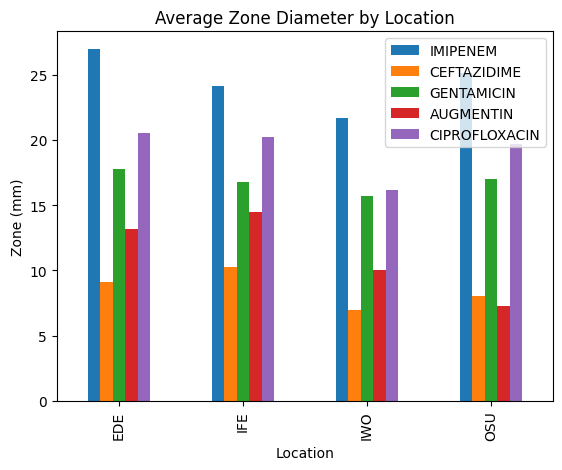

In [85]:
antibiotics = ['IMIPENEM','CEFTAZIDIME','GENTAMICIN','AUGMENTIN','CIPROFLOXACIN']
#location wise analysis
df_nigeria.groupby('Location')[antibiotics].mean().plot(kind='bar')
plt.title("Average Zone Diameter by Location")
plt.ylabel("Zone (mm)")
plt.show()

#bacteria has more susceptibility towards the antibiotic imipenem.

Area wise Analysis

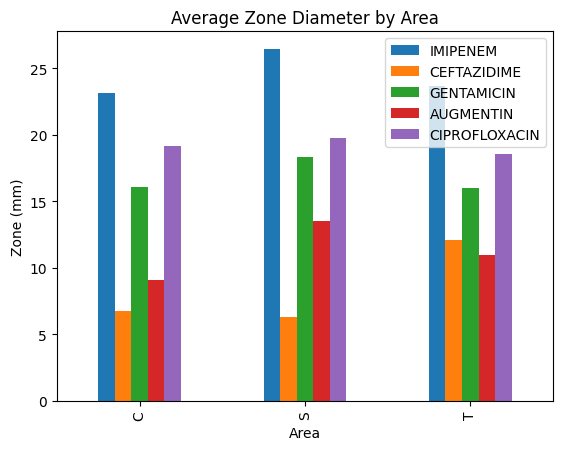

In [86]:
#area wise analysis
df_nigeria.groupby('Area')[antibiotics].mean().plot(kind='bar')
plt.title("Average Zone Diameter by Area")
plt.ylabel("Zone (mm)")
plt.show()



#bacteria has more susceptibility towards the antibiotic imipenem.

Area and Location Combined


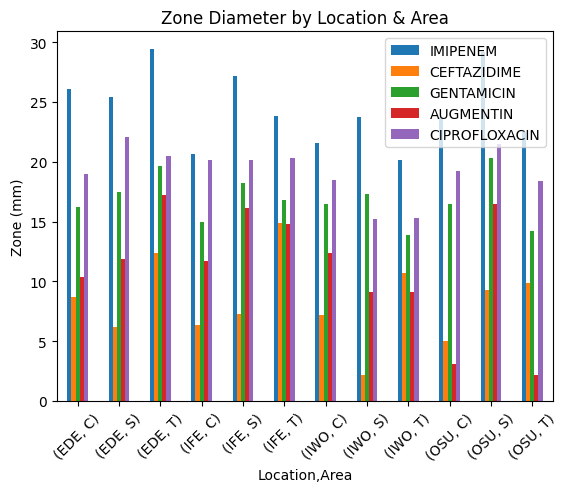

In [87]:

df_nigeria.groupby(['Location','Area'])[antibiotics].mean().plot(kind='bar')
plt.title("Zone Diameter by Location & Area")
plt.ylabel("Zone (mm)")
plt.xticks(rotation=45)
plt.show()

Heatmap Analysis  to visualise if there is any relation


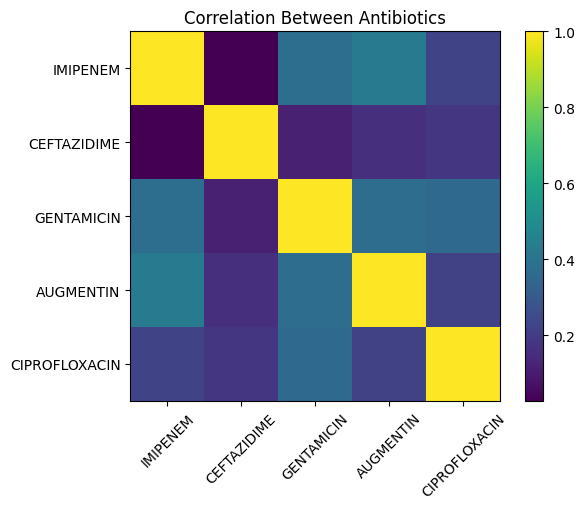

In [88]:

data = df_nigeria[antibiotics].corr()

plt.imshow(data)
plt.colorbar()
plt.xticks(range(len(antibiotics)), antibiotics, rotation=45)
plt.yticks(range(len(antibiotics)), antibiotics)
plt.title("Correlation Between Antibiotics")
plt.show()


#no significant correlation between the antibiotics, suggesting that resistance to one does not necessarily predict resistance to another.

#classification of the antibiotics into S, I, R based on the zone diameter thresholds provided by the Clinical and Laboratory Standards Institute (CLSI) guidelines for Enterobacteriaceae. These thresholds can vary based on the specific antibiotic and the bacterial species being tested
#considering the sample collection area might have more gram negative bacteria, we can use the following thresholds for classification:

In [89]:

def classify_cipro(x):
    if x >= 21: return 'S'
    elif x >= 16: return 'I'       #assuming  there will be many gram negative bacteria.
    else: return 'R'

def classify_imipenem(x):
    if x >= 23: return 'S'
    elif x >= 20: return 'I'       #Most important antibiotic as it last line drug.
    else: return 'R'

def classify_ceftazidime(x):
    if x >= 18: return 'S'
    elif x >= 15: return 'I'
    else: return 'R'

def classify_gentamicin(x):
    if x >= 15: return 'S'
    elif x >= 13: return 'I'
    else: return 'R'

def classify_augmentin(x):
    if x >= 18: return 'S'
    elif x >= 14: return 'I'
    else: return 'R'

df_nigeria['CIPROFLOXACIN'] = df_nigeria['CIPROFLOXACIN'].apply(classify_cipro)
df_nigeria['IMIPENEM'] = df_nigeria['IMIPENEM'].apply(classify_imipenem)
df_nigeria['CEFTAZIDIME'] = df_nigeria['CEFTAZIDIME'].apply(classify_ceftazidime)
df_nigeria['GENTAMICIN'] = df_nigeria['GENTAMICIN'].apply(classify_gentamicin)
df_nigeria['AUGMENTIN'] = df_nigeria['AUGMENTIN'].apply(classify_augmentin)


In [90]:
df_nigeria

,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,Area
0,IFE,S,S,S,I,S,T
1,IFE,S,S,S,S,S,T
2,IFE,S,R,S,S,S,T
3,IFE,S,S,S,S,S,T
4,IFE,S,R,S,S,S,T
...,...,...,...,...,...,...,...
269,EDE,S,R,R,R,S,S
270,EDE,S,R,S,R,S,S
271,EDE,S,S,S,R,S,S
272,EDE,I,R,S,R,I,S


In [91]:

df_encoded = df_nigeria.copy()

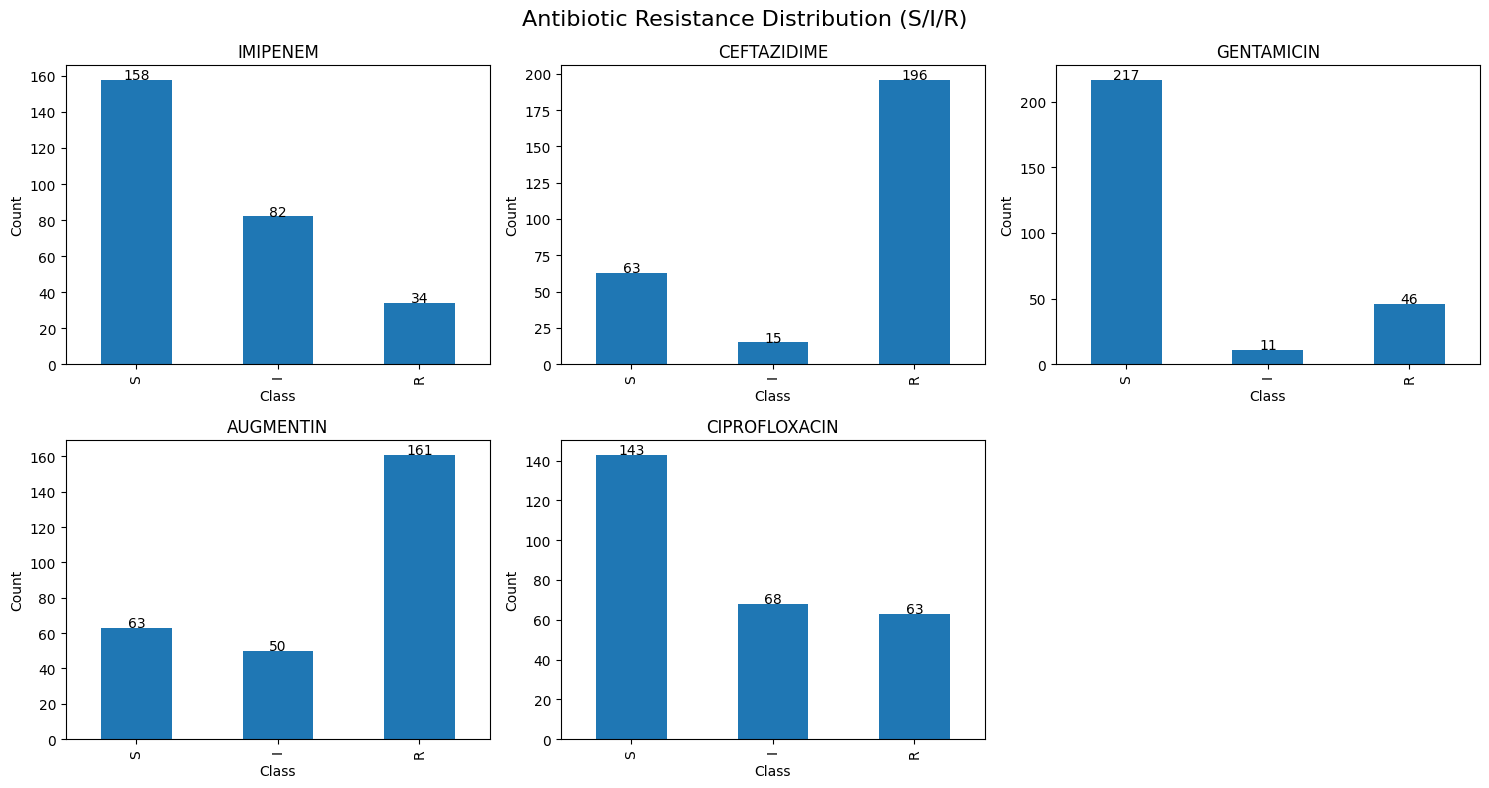

In [92]:
# plotted S I R distribution for each antibiotic
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(antibiotics):
    counts = df_nigeria[col].value_counts().reindex(['S','I','R'])  # keep order
    
    ax = axes[i]
    counts.plot(kind='bar', ax=ax)
    
    ax.set_title(f"{col}")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    
    # Add count labels on bars
    for j, val in enumerate(counts):
        ax.text(j, val + 0.5, str(val), ha='center')

fig.delaxes(axes[-1])

plt.suptitle("Antibiotic Resistance Distribution (S/I/R)", fontsize=16)
plt.tight_layout()
plt.show()

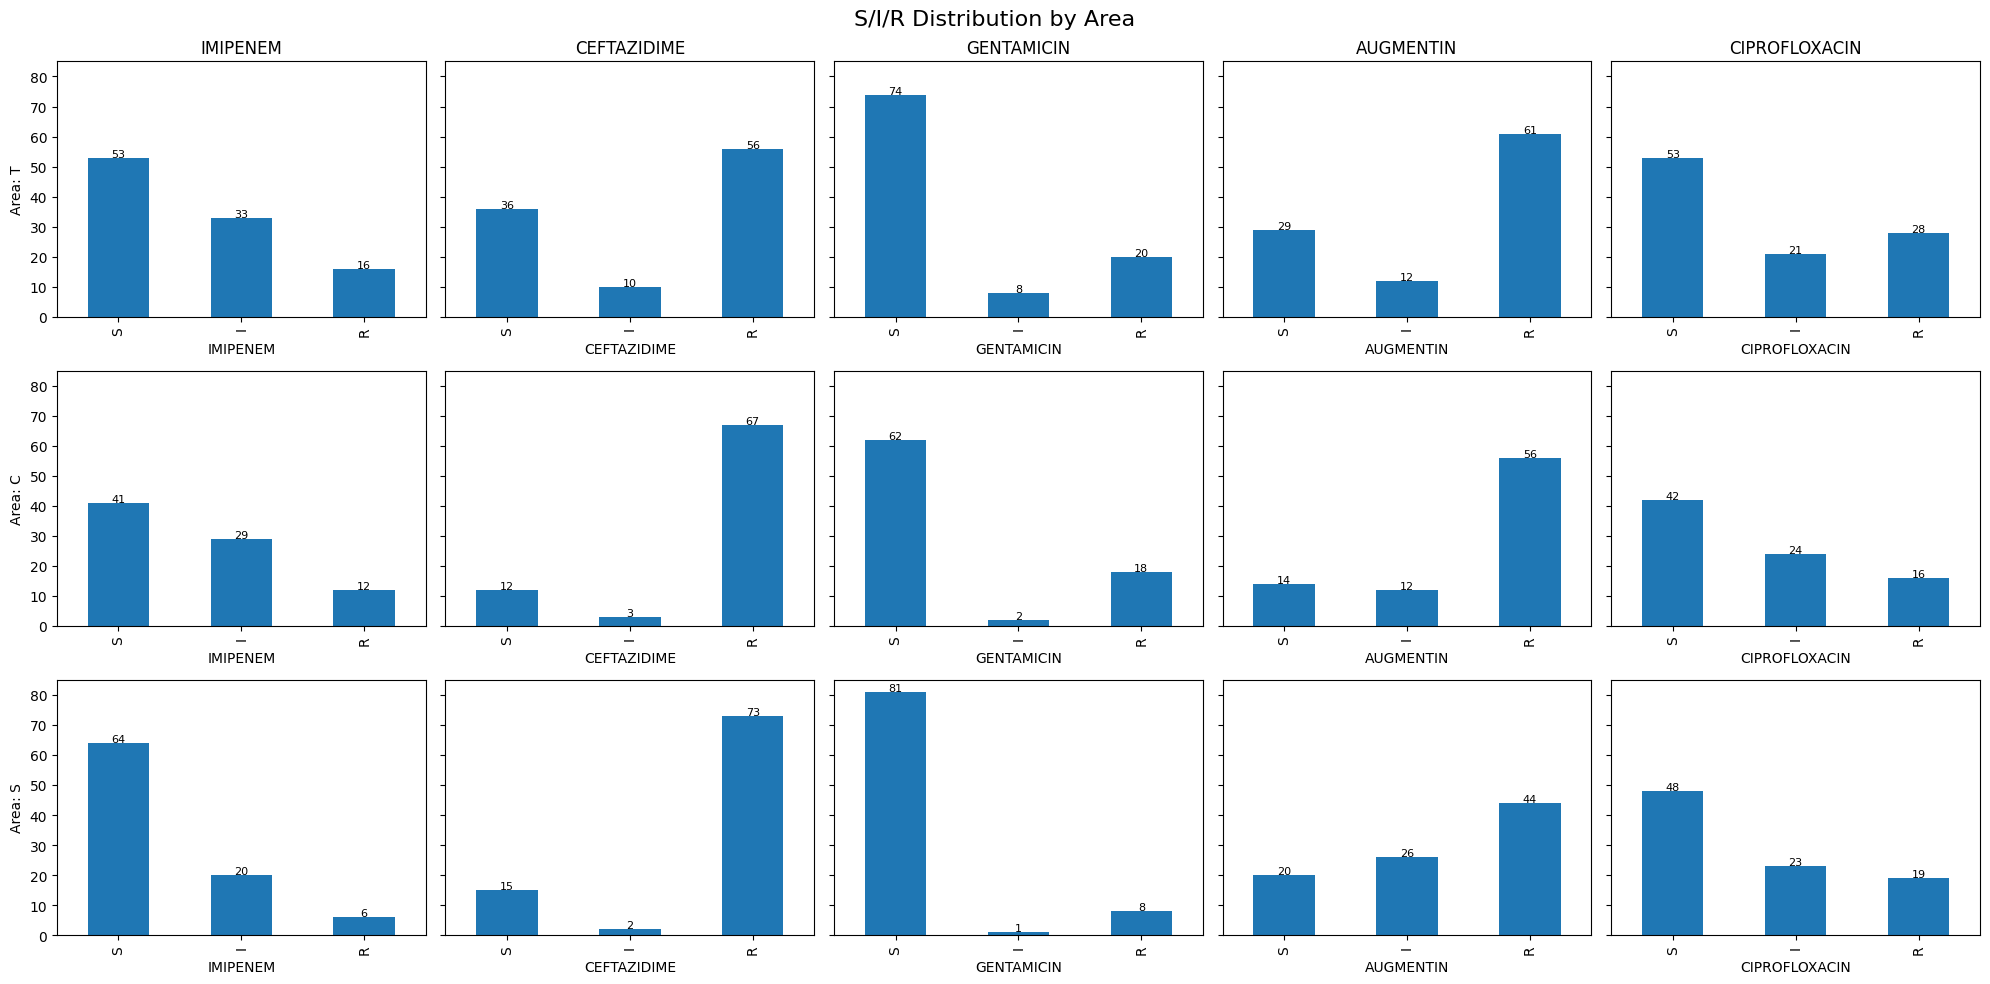

In [93]:
 # S I R distribution by area
areas = df_nigeria['Area'].unique()

fig, axes = plt.subplots(len(areas), len(antibiotics), figsize=(20, 10), sharey=True)

for i, area in enumerate(areas):
    df_area = df_nigeria[df_nigeria['Area'] == area]
    
    for j, col in enumerate(antibiotics):
        counts = df_area[col].value_counts().reindex(['S','I','R'])
        
        ax = axes[i, j]
        counts.plot(kind='bar', ax=ax)
        
        if i == 0:
            ax.set_title(col)
        if j == 0:
            ax.set_ylabel(f"Area: {area}")
        
        # Add counts
        for k, val in enumerate(counts):
            ax.text(k, val + 0.2, str(val), ha='center', fontsize=8)

plt.suptitle("S/I/R Distribution by Area", fontsize=16)
plt.tight_layout()
plt.show()

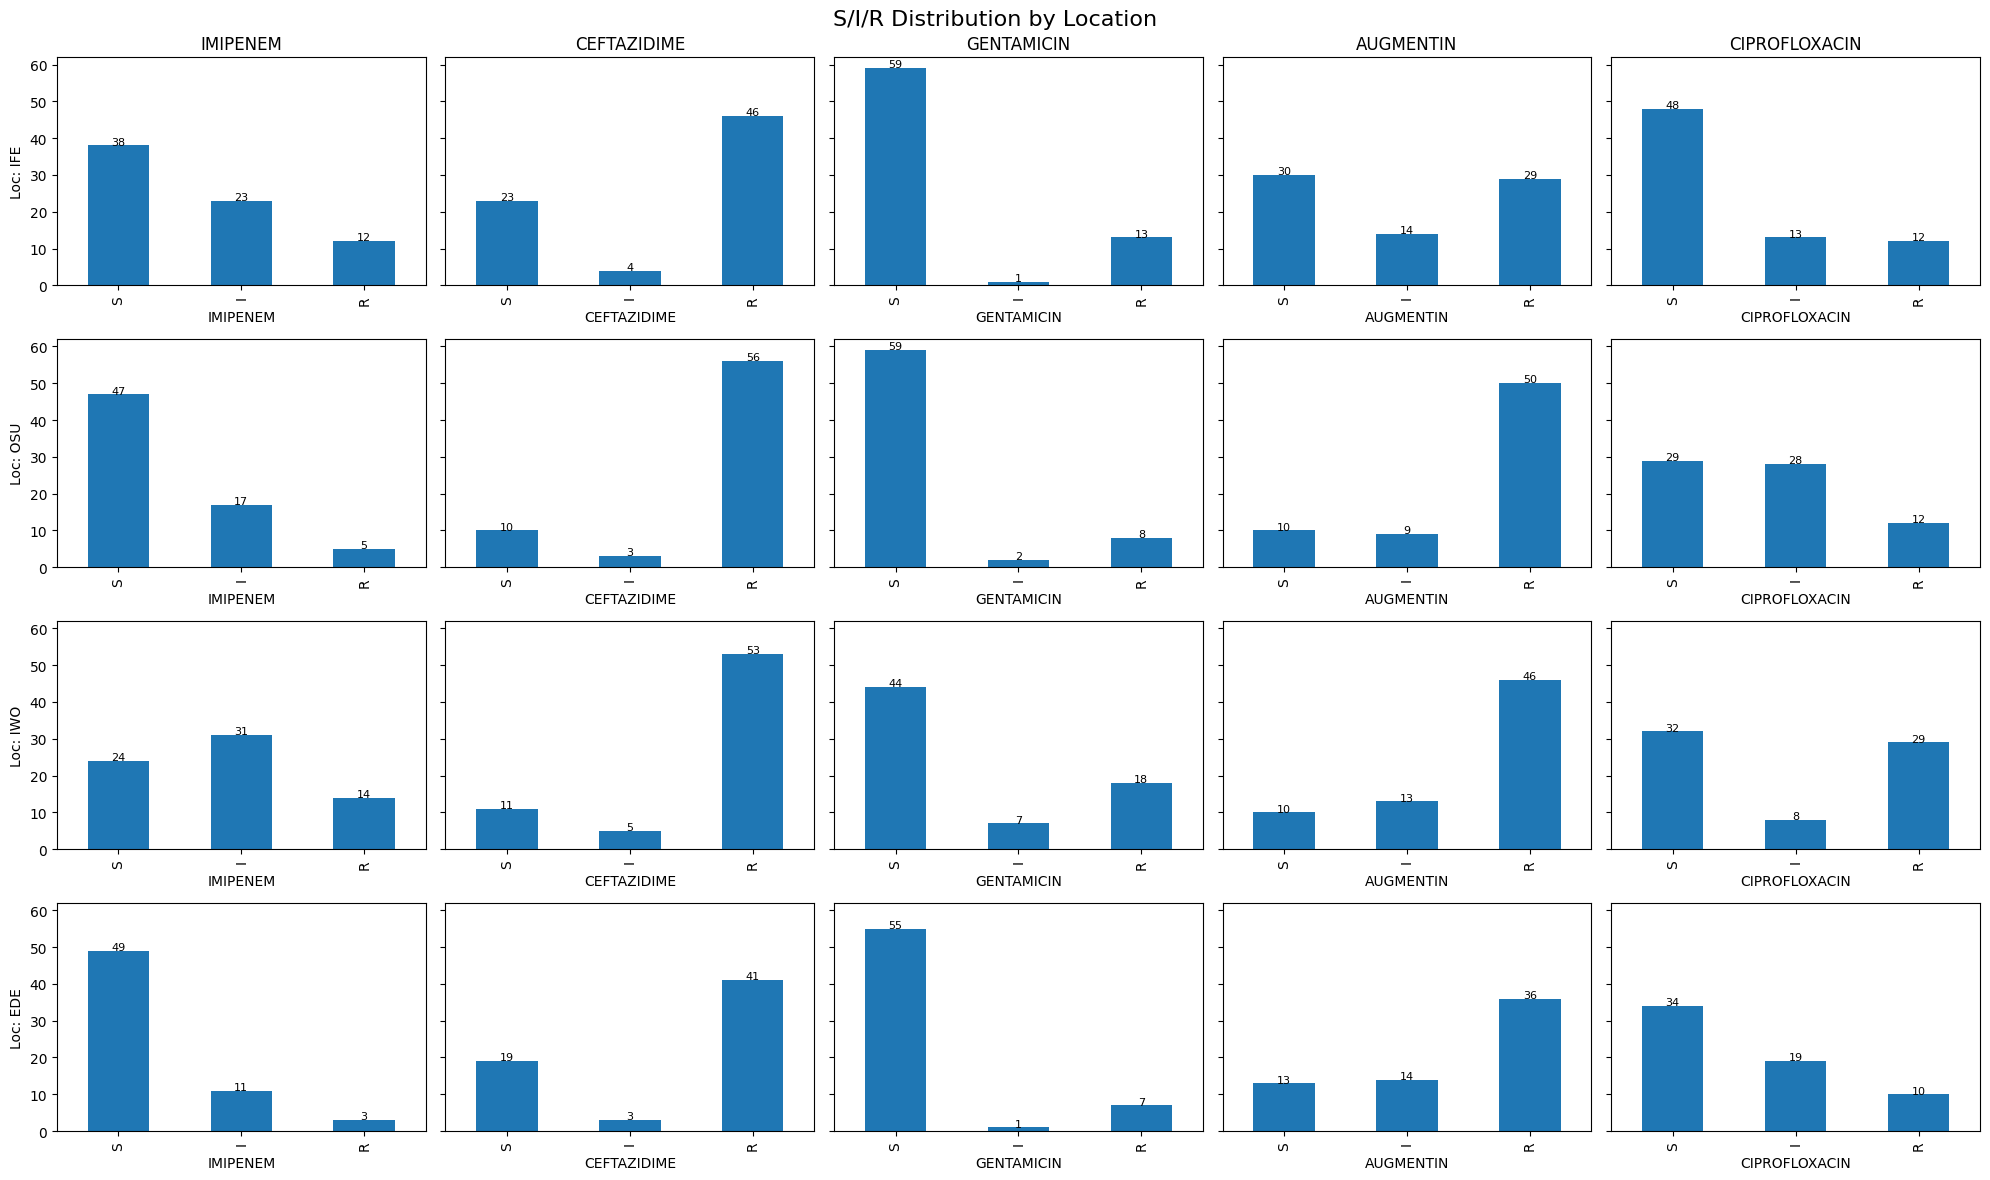

In [94]:
#S I R distribution by location
locations = df_nigeria['Location'].unique()

fig, axes = plt.subplots(len(locations), len(antibiotics), figsize=(20, 12), sharey=True)

for i, loc in enumerate(locations):
    df_loc = df_nigeria[df_nigeria['Location'] == loc]
    
    for j, col in enumerate(antibiotics):
        counts = df_loc[col].value_counts().reindex(['S','I','R'])
        
        ax = axes[i, j]
        counts.plot(kind='bar', ax=ax)
        
        if i == 0:
            ax.set_title(col)
        if j == 0:
            ax.set_ylabel(f"Loc: {loc}")
        
        # Add counts
        for k, val in enumerate(counts):
            ax.text(k, val + 0.2, str(val), ha='center', fontsize=8)

plt.suptitle("S/I/R Distribution by Location", fontsize=16)
plt.tight_layout()
plt.show()

In [95]:
#counting resitance for each sample by counting the number of 'R' classifications across the antibiotics for each row in the dataset. 
# This gives us a new column 'Resistance_Count' that indicates how many antibiotics each sample is resistant to.
df_encoded['Resistance_Count'] = (df_encoded[antibiotics] == 'R').sum(axis=1)

In [96]:
df_encoded

,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,Area,Resistance_Count
0,IFE,S,S,S,I,S,T,0
1,IFE,S,S,S,S,S,T,0
2,IFE,S,R,S,S,S,T,1
3,IFE,S,S,S,S,S,T,0
4,IFE,S,R,S,S,S,T,1
...,...,...,...,...,...,...,...,...
269,EDE,S,R,R,R,S,S,3
270,EDE,S,R,S,R,S,S,2
271,EDE,S,S,S,R,S,S,1
272,EDE,I,R,S,R,I,S,2


flagging samples as HR, VHR, XHR based on the number of antibiotics they are resistant to. For example, we can define:

HR (Highly Resistant): Resistant to 3 antibiotics

VHR (Very Highly Resistant): Resistant to 4 antibiotics

XHR (Extremely Highly Resistant): Resistant to 5 antibiotics

In [97]:

mapping = {3: 'HR', 4: 'VHR', 5: 'XHR'}
df_encoded['Resistance_Level'] = df_encoded['Resistance_Count'].map(mapping).fillna('N')
df_encoded

,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,Area,Resistance_Count,Resistance_Level
0,IFE,S,S,S,I,S,T,0,N
1,IFE,S,S,S,S,S,T,0,N
2,IFE,S,R,S,S,S,T,1,N
3,IFE,S,S,S,S,S,T,0,N
4,IFE,S,R,S,S,S,T,1,N
...,...,...,...,...,...,...,...,...,...
269,EDE,S,R,R,R,S,S,3,HR
270,EDE,S,R,S,R,S,S,2,N
271,EDE,S,S,S,R,S,S,1,N
272,EDE,I,R,S,R,I,S,2,N


saving final dataset with classifications and resistance levels for further analysis or reporting.

Constructed web application using streamlit to visualize the results and provide insights into the antibiotic resistance patterns in the dataset this allows for a comprehensive understanding of the resistance patterns and can help in guiding treatment decisions and public health interventions.

Also suggest the treatment level according to the location or location with area with  probability score.

In [98]:
df_encoded.to_csv('nigeria_encoded.csv', index=False)

   


Link for the wep application https://bacteria-antiobiotics-nigeria.streamlit.app/

We didnt use MDR, XDR, PDR classification as theere are only 5 antibiotics in the dataset which belongs to classes.

beta_lactams': ['IMIPENEM', 'CEFTAZIDIME', 'AUGMENTIN'],

aminoglycosides': ['GENTAMICIN'],

'quinolones': ['CIPROFLOXACIN']

MDR (Multidrug-Resistant): Resistant to at least one antibiotic in three or more classes.

XDR (Extensively Drug-Resistant): Resistant to at least one antibiotic in all but two or fewer classes.
 PDR (Pandrug-Resistant): Resistant to all antibiotics in all classes.
and here we only have classes.

Also IMIPENEM is a carbapenem  which is a last line drug, so resistance to it is particularly concerning and can be considered a marker of high resistance.

A weighted scoring approach was used to reflect the clinical importance of each antibiotic instead of treating all resistance equally.
Imipenem was assigned the highest weight as it is a last-resort drug, and resistance to it indicates severe antimicrobial resistance. 
Ceftazidime and Ciprofloxacin were given moderate weights, while Gentamicin and Amoxicillin-clavulanate were assigned lower weights due 
to their relatively lower clinical impact this ensures the resistance score captures severity more realistically

In [99]:
# Define weights
weights = {
    'IMIPENEM': 5,
    'CEFTAZIDIME': 3,
    'CIPROFLOXACIN': 3,
    'GENTAMICIN': 2,
    'AUGMENTIN': 1
}

# Convert R → 1, others → 0
df_bin = df_encoded[['IMIPENEM','CEFTAZIDIME','CIPROFLOXACIN','GENTAMICIN','AUGMENTIN']].eq('R').astype(int)

# Multiply by weights and sum
df_encoded['resistance_score'] = (
    df_bin['IMIPENEM'] * weights['IMIPENEM'] +
    df_bin['CEFTAZIDIME'] * weights['CEFTAZIDIME'] +
    df_bin['CIPROFLOXACIN'] * weights['CIPROFLOXACIN'] +
    df_bin['GENTAMICIN'] * weights['GENTAMICIN'] +
    df_bin['AUGMENTIN'] * weights['AUGMENTIN']
)

# Normalize score (0 to 1 scale)
max_score = sum(weights.values())
df_encoded['resistance_score_normalized'] = df_encoded['resistance_score'] / max_score

# Optional: Risk category
def categorize(score):
    if score >= 8:
        return "Very High"
    elif score >= 5:
        return "High"
    elif score >= 3:
        return "Moderate"
    else:
        return "Low"

df_encoded['risk_level'] = df_encoded['resistance_score'].apply(categorize)

In [100]:
df_encoded.head()

,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,Area,Resistance_Count,Resistance_Level,resistance_score,resistance_score_normalized,risk_level
0,IFE,S,S,S,I,S,T,0,N,0,0.000000,Low
1,IFE,S,S,S,S,S,T,0,N,0,0.000000,Low
2,IFE,S,R,S,S,S,T,1,N,3,0.214286,Moderate
3,IFE,S,S,S,S,S,T,0,N,0,0.000000,Low
4,IFE,S,R,S,S,S,T,1,N,3,0.214286,Moderate


In [101]:
df_encoded.drop(columns=['Resistance_Level'], inplace=True)

In [102]:
df_encoded['resistance_score_normalized'] = df_encoded['resistance_score_normalized'].round(2)

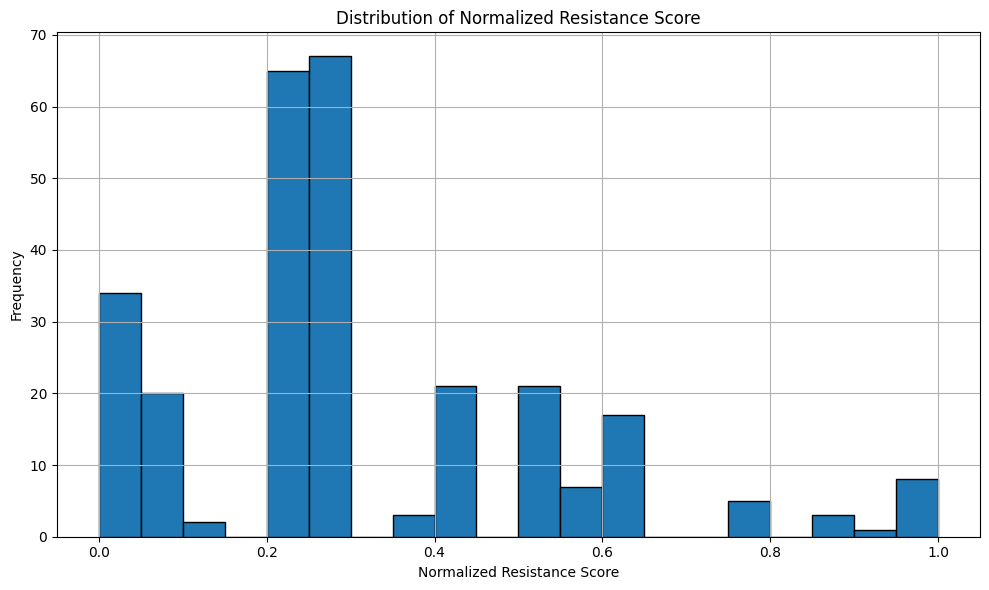

In [103]:
plt.figure(figsize=(10, 6))
df_encoded['resistance_score_normalized'].hist(bins=20, edgecolor='black')
plt.title("Distribution of Normalized Resistance Score")
plt.xlabel("Normalized Resistance Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

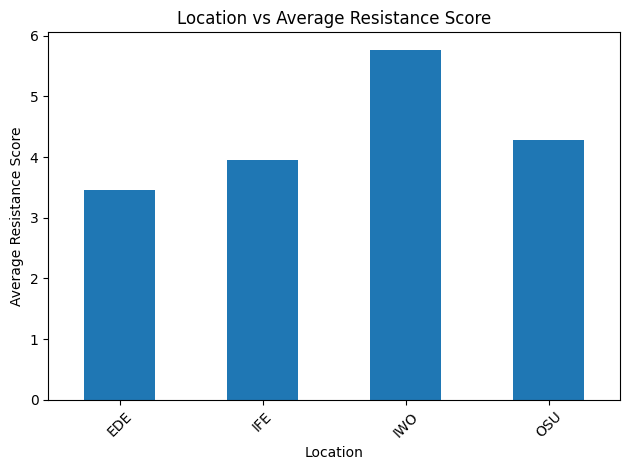

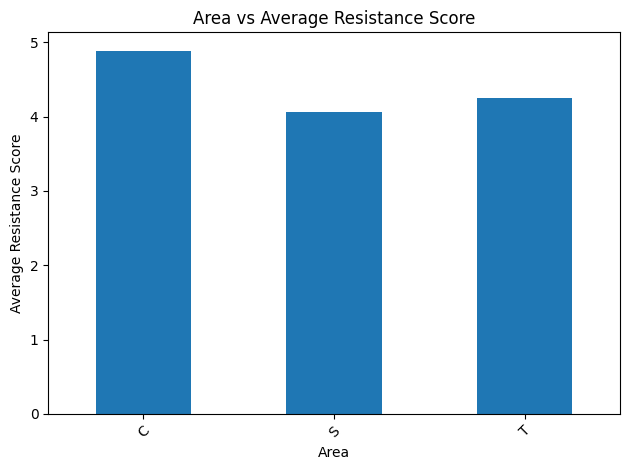

<Figure size 640x480 with 0 Axes>

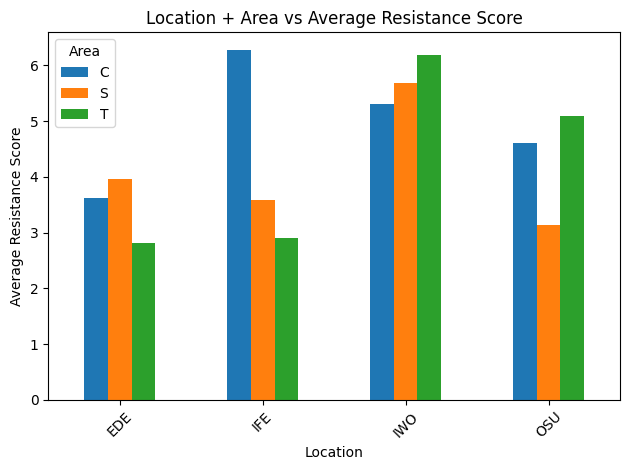

In [104]:
# -----------------------------
# 1. Location vs Resistance Score
# -----------------------------
loc_avg = df_encoded.groupby('Location')['resistance_score'].mean()

plt.figure()
loc_avg.plot(kind='bar')
plt.title("Location vs Average Resistance Score")
plt.xlabel("Location")
plt.ylabel("Average Resistance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Area vs Resistance Score
# -----------------------------
area_avg = df_encoded.groupby('Area')['resistance_score'].mean()

plt.figure()
area_avg.plot(kind='bar')
plt.title("Area vs Average Resistance Score")
plt.xlabel("Area")
plt.ylabel("Average Resistance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Location + Area vs Resistance Score
# -----------------------------
combo_avg = df_encoded.groupby(['Location','Area'])['resistance_score'].mean().unstack()

plt.figure()
combo_avg.plot(kind='bar')
plt.title("Location + Area vs Average Resistance Score")
plt.xlabel("Location")
plt.ylabel("Average Resistance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()